<a href="https://colab.research.google.com/github/GCSvoyager/Data-Mining-x-Soft-Eng/blob/main/Copy_of_%5BPhase_3%5D_Singsing_ng_Apoy_ng_Pasipiko.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

df = pd.read_csv('https://github.com/GCSvoyager/Phase-3/raw/refs/heads/main/Earthquake(Processed).csv')
df.head()

,mag,tsunami,sig,longitude,latitude,depth,depth_z,sig_z,rms_z,longitude_mm,latitude_mm,depth_class,mag_class
0,3.0,0,138,125.518,11.891,33.0,-0.390969,-3.787658,-0.157311,0.456592,0.419850,Shallow,Minor
1,3.0,0,138,125.591,4.094,143.0,0.678179,-3.787658,-0.005495,0.460590,0.073147,Intermediate,Minor
2,3.1,0,148,119.372,17.215,10.0,-0.614518,-3.577598,-0.309127,0.119954,0.656588,Shallow,Minor
3,3.2,0,158,120.818,17.590,10.0,-0.614518,-3.367537,1.209035,0.199156,0.673262,Shallow,Minor
4,3.3,0,168,124.343,4.770,390.3,3.081818,-3.157477,-0.726622,0.392233,0.103206,Deep,Minor


In [ ]:
from sklearn.model_selection import train_test_split

# Choose features and labels
X = df[['longitude_mm', 'latitude_mm', 'tsunami', 'sig_z', 'rms_z']]
y = df['risk_encoded']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # VERY important for classification
)

In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred_lr = model.predict(X_test)

In [ ]:
# Evaluation Metrics: Logistic Regression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.6926358329591379
[[ 348  894   15    0]
 [ 264 2523   63    0]
 [   0  131  214    0]
 [   0    0    2    0]]
              precision    recall  f1-score   support

           0       0.57      0.28      0.37      1257
           1       0.71      0.89      0.79      2850
           2       0.73      0.62      0.67       345
           3       0.00      0.00      0.00         2

    accuracy                           0.69      4454
   macro avg       0.50      0.45      0.46      4454
weighted avg       0.67      0.69      0.66      4454



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
# Evaluation Metrics: Random Forest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8257745846430176
[[ 829  421    7    0]
 [ 268 2526   56    0]
 [   1   21  323    0]
 [   0    1    1    0]]
              precision    recall  f1-score   support

           0       0.76      0.66      0.70      1257
           1       0.85      0.89      0.87      2850
           2       0.83      0.94      0.88       345
           3       0.00      0.00      0.00         2

    accuracy                           0.83      4454
   macro avg       0.61      0.62      0.61      4454
weighted avg       0.82      0.83      0.82      4454



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Hyperparameter Tuning

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report

# Features & target
X = df[['sig_z', 'rms_z', 'longitude_mm', 'latitude_mm']]
y = df['risk_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Hyperparameter grid
param_grid = {
    'n_estimators': [200, 400, 600],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

# Grid search
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           scoring='f1_macro', cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Best parameters and evaluation
print("Best Parameters:", grid_search.best_params_)
y_pred = grid_search.predict(X_test)
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 162 candidates, totalling 486 fits


KeyboardInterrupt: 

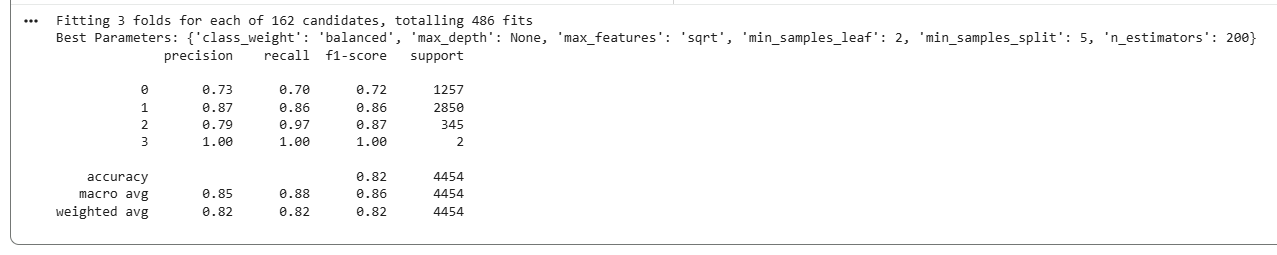

In [ ]:
# Additional Metric for the GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

NameError: name 'y_pred' is not defined

In [ ]:
# Random Forest with hyperparameter-tuned settings
from sklearn.ensemble import RandomForestClassifier

rf_2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    max_features='sqrt',
    random_state=42
)

rf_2.fit(X_train, y_train)

y_pred_rf_2 = rf_2.predict(X_test)

In [ ]:
# Evaluation Metrics: Random Forest with hyperparameter-tuned settings
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf_2))
print(confusion_matrix(y_test, y_pred_rf_2))
print(classification_report(y_test, y_pred_rf_2))

Accuracy: 0.819488100583745
[[ 874  373   10    0]
 [ 329 2435   86    0]
 [   2    4  339    0]
 [   0    0    0    2]]
              precision    recall  f1-score   support

           0       0.73      0.70      0.71      1257
           1       0.87      0.85      0.86      2850
           2       0.78      0.98      0.87       345
           3       1.00      1.00      1.00         2

    accuracy                           0.82      4454
   macro avg       0.84      0.88      0.86      4454
weighted avg       0.82      0.82      0.82      4454



In [ ]:
# Feature Importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Feature names - corrected to match the 5 features used in X_train for rf_2
features = ['longitude_mm', 'latitude_mm', 'tsunami', 'sig_z', 'rms_z']

# Extract importance
importances = rf_2.feature_importances_

# Create a DataFrame
feat_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp_df)

        Feature  Importance
3         sig_z    0.614112
1   latitude_mm    0.164365
0  longitude_mm    0.132085
4         rms_z    0.089438
2       tsunami    0.000000


/tmp/ipykernel_524/1559958790.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


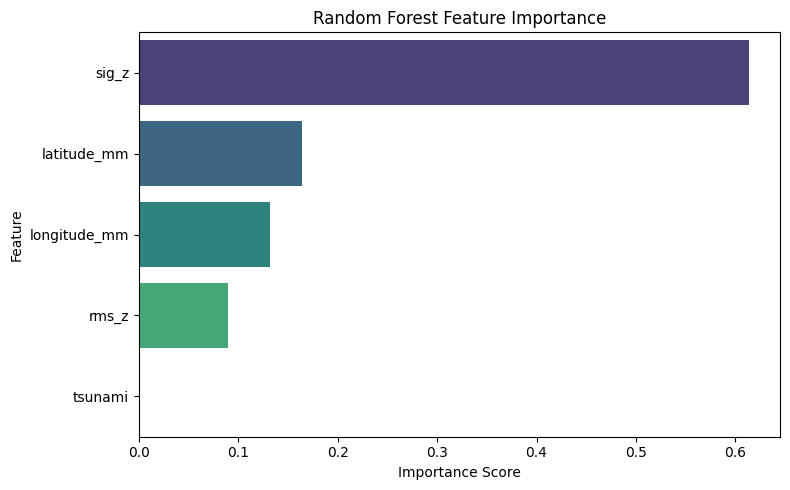

In [ ]:
# Plot feature importance
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

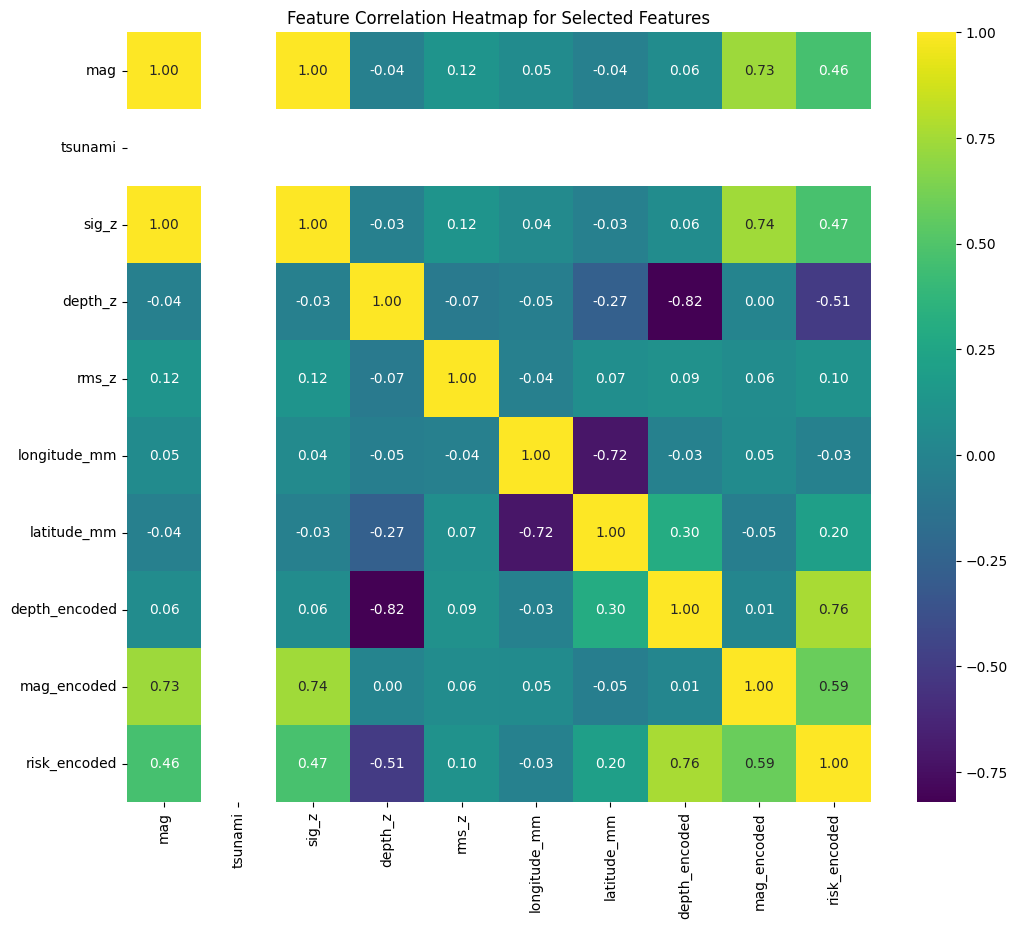

In [ ]:
selected_columns = ['mag', 'tsunami', 'sig_z', 'depth_z', 'rms_z', 'longitude_mm', 'latitude_mm', 'depth_encoded', 'mag_encoded', 'risk_encoded']
filtered_df = df[selected_columns]

plt.figure(figsize=(12, 10)) # Increased figure size for better visibility
sns.heatmap(filtered_df.corr(numeric_only=True), annot=True, cmap='viridis', fmt=".2f")
plt.title("Feature Correlation Heatmap for Selected Features")
plt.show()